In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import torch
from torch.utils.data import DataLoader

from satx.data import EuroSATDataset, CLASS_NAMES
from satx.visualization import show_RGB

# 1. Standard Split

## 1.1 13 Bands Multispectral Dataset

In [2]:
# Create MS train/test datasets (using standard splits)
ms_train_std = EuroSATDataset(modality='ms', split_type='standard', split='train')
ms_test_std = EuroSATDataset(modality='ms', split_type='standard', split='test')

print(f"Multispectral Train set size: {len(ms_train_std)}")
print(f"Multispectral Test set size: {len(ms_test_std)}")

# Fetch a single sample
ms_img_std, ms_label_std = ms_train_std[0]
print(f"Image shape: {ms_img_std.shape}")
print(f"Label ID: {ms_label_std} ({CLASS_NAMES[ms_label_std]})")

Multispectral Train set size: 16200
Multispectral Test set size: 5400
Image shape: torch.Size([13, 64, 64])
Label ID: 7 (Residential)


In [3]:
# Create DataLoader
train_loader_std = DataLoader(ms_train_std, batch_size=32, shuffle=True, num_workers=2)

# Fetch one batch
for imgs_std, labels_std in train_loader_std:
    print("Batch loaded successfully!")
    print("Batch images shape:", imgs_std.shape)
    print("Batch labels shape:", labels_std.shape)
    break

Batch loaded successfully!
Batch images shape: torch.Size([32, 13, 64, 64])
Batch labels shape: torch.Size([32])


## 1.2. RGB Datasets

In [4]:
# Create RGB train/test datasets (using standard splits)
rgb_train_std = EuroSATDataset(modality='rgb', split_type='standard', split='train')
rgb_test_std = EuroSATDataset(modality='rgb', split_type='standard', split='test')

print(f"RGB Train set size: {len(rgb_train_std)}")
print(f"RGB Test set size: {len(rgb_test_std)}")

# Fetch a single sample
rgb_img_std, rgb_label_std = rgb_train_std[0]
print(f"Image shape: {rgb_img_std.shape}")
print(f"Label ID: {rgb_label_std} ({CLASS_NAMES[rgb_label_std]})")

RGB Train set size: 16200
RGB Test set size: 5400
Image shape: torch.Size([3, 64, 64])
Label ID: 7 (Residential)


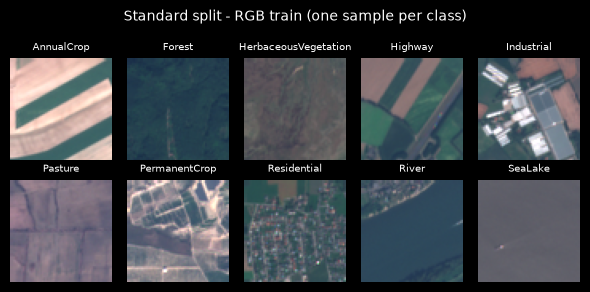

In [5]:
show_RGB(rgb_train_std, "Standard split - RGB train (one sample per class)")

# 2. Spatial Split

## 2.1 13 Bands Multispectral Dataset

In [6]:
# Create MS train/test datasets (using spatial splits)
ms_train_ss = EuroSATDataset(modality='ms', split_type='spatial', split='train')
ms_test_ss = EuroSATDataset(modality='ms', split_type='spatial', split='test')

print(f"Multispectral Train set size: {len(ms_train_ss)}")
print(f"Multispectral Test set size: {len(ms_test_ss)}")

# Fetch a single sample
ms_img, ms_label = ms_train_ss[0]
print(f"Image shape: {ms_img.shape}")
print(f"Label ID: {ms_label} ({CLASS_NAMES[ms_label]})")

Multispectral Train set size: 16200
Multispectral Test set size: 5400
Image shape: torch.Size([13, 64, 64])
Label ID: 6 (PermanentCrop)


In [7]:
# Create DataLoader
train_loader = DataLoader(ms_train_ss, batch_size=32, shuffle=True, num_workers=2)

# Fetch one batch
for imgs, labels in train_loader:
    print("Batch loaded successfully!")
    print("Batch images shape:", imgs.shape)
    print("Batch labels shape:", labels.shape)
    break

Batch loaded successfully!
Batch images shape: torch.Size([32, 13, 64, 64])
Batch labels shape: torch.Size([32])


## 2.2. RGB Datasets

In [8]:
rgb_train_ss = EuroSATDataset(modality='rgb', split_type='spatial', split='train')
rgb_test_ss = EuroSATDataset(modality='rgb', split_type='spatial', split='test')

print(f"RGB Train set size: {len(rgb_train_ss)}")
print(f"RGB Test set size: {len(rgb_test_ss)}")

# Fetch a single sample
rgb_img, rgb_label = rgb_train_ss[0]
print(f"Image shape: {rgb_img.shape}")
print(f"Label ID: {rgb_label} ({CLASS_NAMES[rgb_label]})")

RGB Train set size: 16200
RGB Test set size: 5400
Image shape: torch.Size([3, 64, 64])
Label ID: 6 (PermanentCrop)


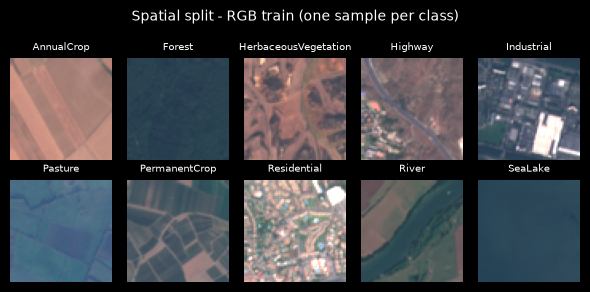

In [9]:
show_RGB(rgb_train_ss, "Spatial split - RGB train (one sample per class)")

# 3. W1-C Training Pipeline

This section documents the reusable ResNet-50 model factory and config-driven training engine added for W1-C. The implementation lives in `src/satx/models/` and `src/satx/engine/`; this notebook is only a lightweight usage note and smoke-test guide.

PyTorch, torchvision, and TorchGeo are intentionally not pinned here because each teammate may need a device-specific install (CUDA, MPS, or CPU). If those packages are missing, the smoke-test cell below will skip model construction instead of failing the whole notebook.

## 3.1 Training configuration examples

The next cells show how to create W1-C training configs directly in Python and how to load equivalent reusable YAML configs from `configs/`.

In [11]:
from satx.engine import TrainingConfig, load_training_config

rgb_config = TrainingConfig(
    modality="rgb",
    split_type="spatial",
    epochs=1,
    batch_size=16,
    pretrained=False,
)

ms_config = TrainingConfig(
    modality="ms",
    split_type="spatial",
    model_input_mode="direct",
    epochs=1,
    batch_size=16,
    pretrained=False,
)

print(rgb_config)
print(ms_config)

TrainingConfig(modality='rgb', split_type='spatial', data_dir='./data', splits_dir='./splits_data', output_dir='./outputs/runs', model_input_mode='direct', num_classes=10, pretrained=False, epochs=1, batch_size=16, num_workers=0, learning_rate=0.001, weight_decay=0.0001, seed=42, device='auto', pin_memory=True)
TrainingConfig(modality='ms', split_type='spatial', data_dir='./data', splits_dir='./splits_data', output_dir='./outputs/runs', model_input_mode='direct', num_classes=10, pretrained=False, epochs=1, batch_size=16, num_workers=0, learning_rate=0.001, weight_decay=0.0001, seed=42, device='auto', pin_memory=True)


In [12]:
# The same settings can be loaded from reusable config files.
# Support running the notebook from either the project root or notebooks/.
from pathlib import Path

config_dir = Path("configs") if Path("configs").exists() else Path("../configs")
loaded_rgb_config = load_training_config(config_dir / "rgb_spatial.yaml")
loaded_ms_config = load_training_config(config_dir / "ms_spatial.yaml")

print(loaded_rgb_config.run_name)
print(loaded_ms_config.run_name)

resnet50_rgb_spatial_direct_scratch_seed42
resnet50_ms_spatial_direct_scratch_seed42


## 3.2 Model construction smoke test

This lightweight check builds RGB and multispectral ResNet-50 models and runs dummy tensors through them. It verifies model construction and output shapes without reading data or training weights.


In [13]:
# Model construction smoke test.
# This is safe to run only after installing torch and torchvision for your device.
try:
    import torch
    from satx.models import build_resnet50
except ImportError as exc:
    print(f"Skipping model smoke test: {exc}")
else:
    rgb_model = build_resnet50(
        in_channels=rgb_config.in_channels,
        num_classes=rgb_config.num_classes,
        pretrained=rgb_config.pretrained,
        input_mode=rgb_config.model_input_mode,
    )
    ms_model = build_resnet50(
        in_channels=ms_config.in_channels,
        num_classes=ms_config.num_classes,
        pretrained=ms_config.pretrained,
        input_mode=ms_config.model_input_mode,
    )

    rgb_model.eval()
    ms_model.eval()
    with torch.no_grad():
        rgb_logits = rgb_model(torch.zeros(2, 3, 64, 64))
        ms_logits = ms_model(torch.zeros(2, 13, 64, 64))

    print("RGB logits shape:", tuple(rgb_logits.shape))
    print("MS logits shape:", tuple(ms_logits.shape))

RGB logits shape: (2, 10)
MS logits shape: (2, 10)


## 3.3 Optional local training and evaluation smoke tests

Run these only after EuroSAT_MS is available under `../data/EuroSAT_MS` and the device-specific PyTorch/TorchGeo stack is installed. Step 1 runs a one-epoch W1-C training smoke test and stores the returned `history`. Step 2 reuses that `history` to exercise the W1-D evaluation artifact and plotting helpers. Set the smoke-test flags intentionally so restarting the shared notebook does not accidentally launch training or write evaluation outputs.

### 3.3.1 Step 1: W1-C training smoke test


In [15]:
RUN_TRAINING_SMOKE_TEST = False

if RUN_TRAINING_SMOKE_TEST:
    from satx.engine import fit

    smoke_config = TrainingConfig(
        modality="rgb",
        split_type="spatial",
        epochs=1,
        batch_size=16,
        pretrained=False,
    )

    history = fit(smoke_config)

    print("Training smoke test completed.")
    print("best_epoch:", history["best_epoch"])
    print("best_val_accuracy:", history["best_val_accuracy"])
    print("num_epochs:", len(history["epochs"]))
    print("run_dir:", smoke_config.run_dir())
else:
    print(
        "Set RUN_TRAINING_SMOKE_TEST = True after installing dependencies "
        "and downloading EuroSAT_MS."
    )


Training smoke test completed.
best_epoch: 1
best_val_accuracy: 0.5651851851851852
num_epochs: 1
run_dir: /home/windhurt/dl_projects/projects/satx-eurosat-geographic-generalization-study/outputs/runs/resnet50_rgb_spatial_direct_scratch_seed42


### 3.3.2 Step 2: W1-D evaluation smoke test

Run this after Step 1 has produced `history`. It uses the final validation epoch's `y_true` and `y_pred` values, so it can be rerun without repeating training as long as `history` is still available in the notebook kernel.


In [17]:
RUN_EVALUATION_SMOKE_TEST = False

if RUN_EVALUATION_SMOKE_TEST:

    from satx.eval import (
        generate_evaluation_artifact,
        plot_evaluation_results,
        print_evaluation_results,
    )

    output_dir = smoke_config.evaluation_dir("validation")
    output_dir.mkdir(parents=True, exist_ok=True)

    last_val = history["epochs"][-1]["val"]
    y_true = last_val["y_true"]
    y_pred = last_val["y_pred"]

    artifact = generate_evaluation_artifact(
        y_true,
        y_pred,
        output_path=str(output_dir / "evaluation_artifact.json"),
    )

    print_evaluation_results(artifact)
    plot_evaluation_results(artifact, output_dir=str(output_dir))
else:
    print("Set RUN_EVALUATION_SMOKE_TEST = True after training history is available.")


Evaluation artifact successfully saved to: /home/windhurt/dl_projects/projects/satx-eurosat-geographic-generalization-study/outputs/runs/resnet50_rgb_spatial_direct_scratch_seed42/evaluation/validation/evaluation_artifact.json

EVALUATION RESULTS SUMMARY
Overall Accuracy : 0.5652
Macro F1 Score   : 0.5458
-------------------------------------------------------
Per-Class F1 Scores:
  - AnnualCrop               : 0.4573
  - Forest                   : 0.5845
  - HerbaceousVegetation     : 0.5608
  - Highway                  : 0.4461
  - Industrial               : 0.7465
  - Pasture                  : 0.2008
  - PermanentCrop            : 0.5473
  - Residential              : 0.7476
  - River                    : 0.4559
  - SeaLake                  : 0.7107

Visualizations successfully saved to: /home/windhurt/dl_projects/projects/satx-eurosat-geographic-generalization-study/outputs/runs/resnet50_rgb_spatial_direct_scratch_seed42/evaluation/validation
